In [1]:
import sys
import os
sys.path.append("../../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

##Personal Imports##
from matplotlib.pyplot import plot, scatter, loglog,xlim, ylim, yscale, xscale, title, xlabel, ylabel

from numpy import pi, cos, sin, exp, log, sqrt, array
#import equilibrium_critical_correlations as ecc
from equilibrium_critical_correlations import P_n, sigma_general, P_n_correlations, Dn

In [2]:
correlator_data=[]
for n in range(1,10):

    path = "connected_correlations/"
    file_name = f"corr_connected_n0{n}_r00-200.npy"

    correlator_data.append(np.load(path+file_name))

correlator_data = np.array(correlator_data)

label_list = [f"n = {n}" for n in range(1,len(correlator_data)+1)]

r = np.arange(0,len(correlator_data[0]))

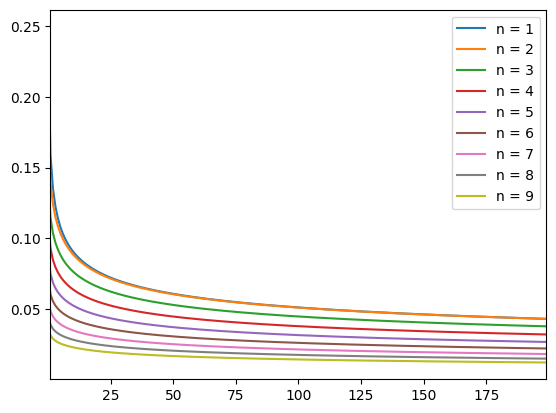

In [3]:
X = np.arange(0,len(correlator_data[0]))
P0 = correlator_data[0]
for i,p in enumerate(correlator_data):
    plot(X,p,label=f"{label_list[i]}")
    xlim(X[1],X[-1])

#plot(X,X**(-1.),label=r"$x^{-1}$",linestyle="--",color="black")
#plot(X,X**(-1/4.),label=r"$x^{-1/2}$",linestyle=":",color="black")
plt.legend()
#loglog()

In [4]:
def large_r_scaling(r,A):
    return A*r**(-1/4)

from scipy.optimize import curve_fit

weights= []
test = []
for P in correlator_data:
    A = curve_fit(large_r_scaling,X[150:],P[150:])[0]
    weights.append(A)
    test.append(np.abs(P-large_r_scaling(X,A)))

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_24948/57879735.py:2: RuntimeWarning: divide by zero encountered in power
  return A*r**(-1/4)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_24948/775028645.py:9: RuntimeWarning: divide by zero encountered in power
  plot(X,X**(-1/4.),label=r"$x^{-1/4}$",linestyle=":",color="black")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_24948/775028645.py:10: RuntimeWarning: divide by zero encountered in power
  plot(X,X**(-1/7.)*correlator_data[-1][1]/weights[-1],label=r"$x^{-1/8}$",linestyle="--",color="black")


(0.3, 1.0)

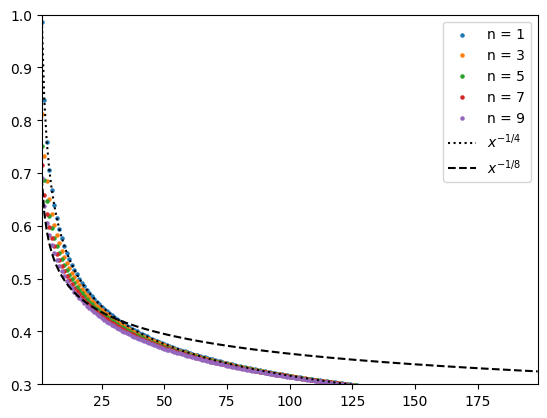

In [5]:
X = np.arange(0,len(correlator_data[0]))
P0 = correlator_data[0]
for i,p in enumerate(correlator_data):
    if i %2 ==0:
        w = weights[i]
        scatter(X,(p)/w,label=f"{label_list[i]}",s=5)
        xlim(X[1],X[-1])

plot(X,X**(-1/4.),label=r"$x^{-1/4}$",linestyle=":",color="black")
plot(X,X**(-1/7.)*correlator_data[-1][1]/weights[-1],label=r"$x^{-1/8}$",linestyle="--",color="black")

#loglog()
plt.legend()
# plt.show()
plt.ylim(0.3,1)
# plt.legend()

# for i,p in enumerate(correlator_data):
#     w = weights[i]
#     scatter(X,X**(-1/4)-(p)/w,label=f"{label_list[i]}")

#     plot(X,P0/weights[0]-(p)/w,label=f"{label_list[i]}")
#     xlim(X[1],X[-1])

# plot(X,X**(-1.),label=r"$x^{-1}$",linestyle="--",color="black")
# plt.legend()
# loglog()
#ylim(0.25,1)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_24948/464490765.py:10: RuntimeWarning: divide by zero encountered in power
  plot(X,X**(-1.)*test[1][1],label=r"$x^{-1}$",linestyle=":",color="black")


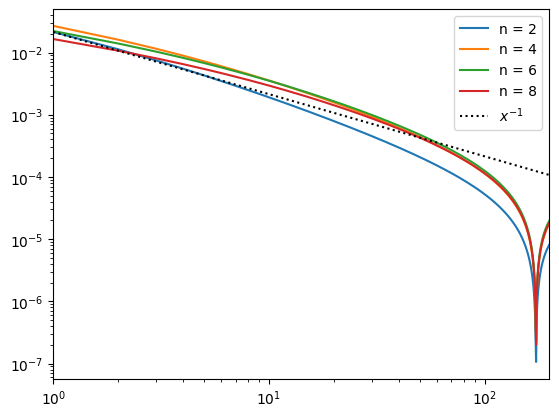

In [6]:
P0 = correlator_data[0]
for i,p in enumerate(correlator_data):
    if i ==0:
        pass
    elif i%2!=0:
        w = weights[i]
        plot(X,test[i],label=f"{label_list[i]}")
        xlim(X[1],X[-1])
#plot(X,X**(-2.)*test[1][1],label=r"$x^{-2}$",linestyle="--",color="black")
plot(X,X**(-1.)*test[1][1],label=r"$x^{-1}$",linestyle=":",color="black")
plt.legend()
loglog()
plt.show()

[array([0.02136356, 1.        ]), array([0.02822619, 1.        ]), array([0.02942992, 1.        ]), array([0.0280363, 1.       ]), array([0.02549463, 1.        ]), array([0.02254394, 1.        ]), array([0.01956945, 1.        ]), array([0.01676718, 1.        ])]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_24948/1878553676.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  A = curve_fit(small_r_scaling,X[1:50],test[i][1:50])[0]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_24948/1878553676.py:2: RuntimeWarning: divide by zero encountered in power
  return A*r**(-1.)


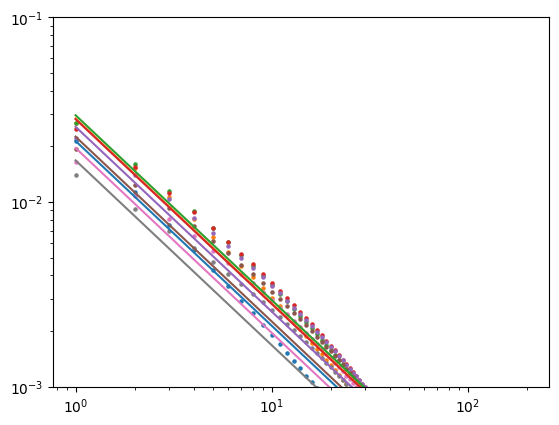

In [7]:
def small_r_scaling(r,A,b):
    return A*r**(-1.)

from scipy.optimize import curve_fit

weights_2= []
for i in range(1,len(test)):
    A = curve_fit(small_r_scaling,X[1:50],test[i][1:50])[0]
    plot(X,small_r_scaling(X,*A),label=f"{i+1}")
    scatter(X,test[i],s=5)
    weights_2.append(A)
loglog()
ylim(.001,.1)
print(weights_2)
#legend()

In [8]:
P0 = correlations[0]
for i,p in enumerate(correlations):
    if i ==0:
        pass
    else:
        w = weights_2[i]
        plot(X,test[i]/w,label=f"n={ns[i]}")
        xlim(X[1],X[-1])
plt.xlim(1,50)
#plot(X,X**(-2.)*test[1][1],label=r"$x^{-2}$",linestyle="--",color="black")
#plot(X,X**(-1.)*test[1][1],label=r"$x^{-1/4}$",linestyle=":",color="black")
plt.legend()
loglog()
plt.show()

NameError: name 'correlations' is not defined

In [9]:
X = np.arange(0,len(correlations[0]))
P0 = correlations[0]
for i,p in enumerate(correlations):
    w = weights[i]
    plot(X*(i+1),(p)/w,label=f"n={ns[i]}")
    xlim(X[1],X[-1])
plot(X,X**(-1/4.),label=r"$x^{-1/4}$",linestyle=":",color="black")
loglog()
legend()
plt.show()




NameError: name 'correlations' is not defined

In [10]:
import numpy as np
from scipy.optimize import curve_fit

def an(r, A):
    return np.power(A, r).astype(float)

# r and weights must be defined beforehand and satisfy:
# len(r) == len(weights)
n=np.array([1,2,3,4,5,6,7,8,9])
t = np.array([weights[i]/weights[0]*(4**i) for i in range(len(n))], dtype=float)

params, _ = curve_fit(an, r, t)
print(params[0])


ValueError: object too deep for desired array

error: Result from function call is not a proper array of floats.

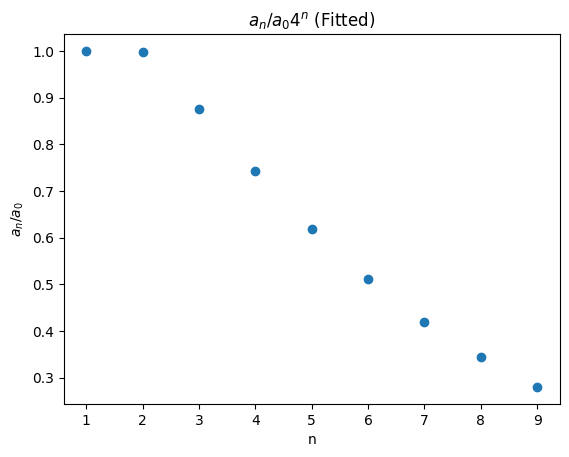

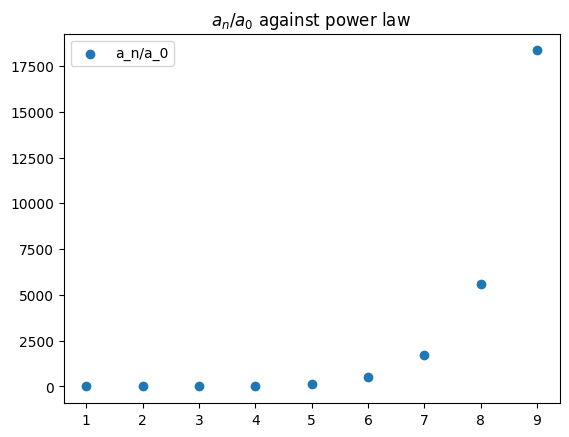

In [14]:
plt.scatter(n,weights/weights[0])
plt.title(r"$a_n/{a_0 4^n}$ (Fitted)")
#plt.plot(n+1,(3.35**(n-1)/4**(n-1)),label=r"$3.44^{n-1}$")

plt.xlabel("n")
plt.ylabel(r"$a_n/a_0$")
plt.show()
plt.title(r"$a_n/{a_0}$ against power law ")

plt.scatter(n,t,label=r"a_n/a_0")
#plt.plot(n,3.35**(n-1),label=r"$3.44^{n-1}$")
plt.legend()
#plt.loglog()


In [20]:
[weights[n]/weights[0]*(4**(n)) for n in range(0,9)]

[array([1.]),
 array([3.99426004]),
 array([14.02246034]),
 array([47.49414988]),
 array([158.30672427]),
 array([522.97683215]),
 array([1717.96036362]),
 array([5621.59192113]),
 array([18343.41250938])]